Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


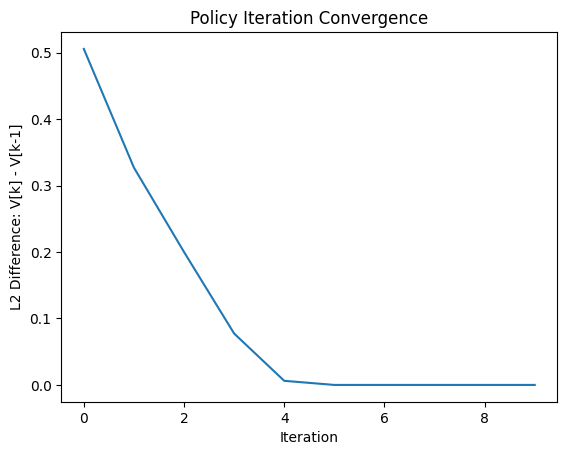

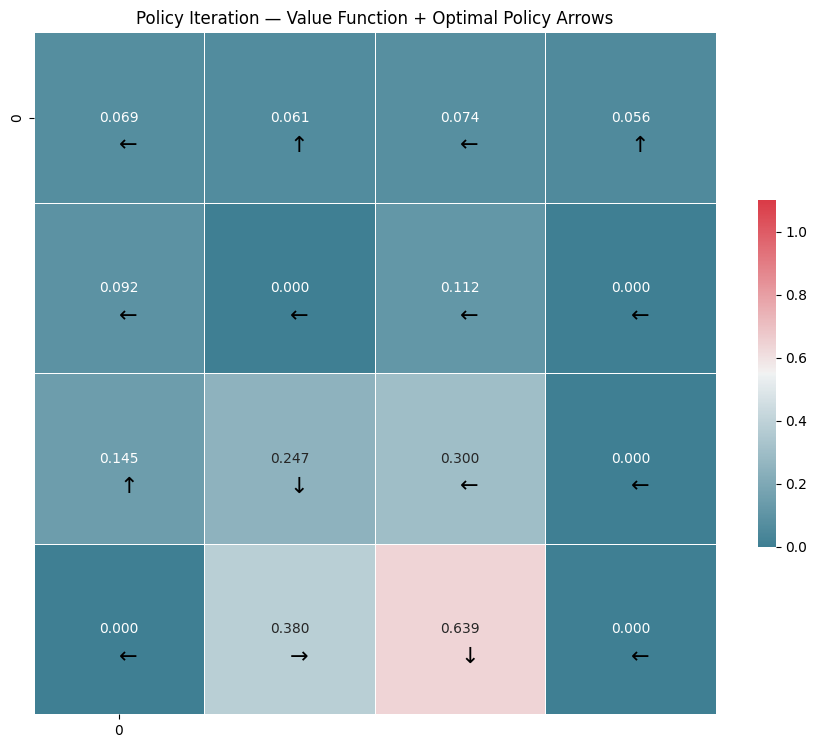


Value Function:
 [0.06888359 0.06140837 0.07440524 0.05580235 0.09184788 0.
 0.11220577 0.         0.14543097 0.24749332 0.29961504 0.
 0.         0.37993328 0.63901878 0.        ]

Policy:
 [0, 3, 0, 3, 0, 0, 0, 0, 3, 1, 0, 0, 0, 2, 1, 0]

Optimal Q Function:

[[0.06888452 0.06664195 0.06664195 0.05975266]
 [0.03908759 0.04298665 0.04074408 0.06140916]
 [0.07440581 0.06882495 0.07272401 0.05748479]
 [0.03906228 0.03906228 0.03348141 0.05580298]
 [0.09184873 0.07118366 0.06429437 0.04821944]
 [0.         0.         0.         0.        ]
 [0.11220608 0.08988451 0.11220608 0.02232157]
 [0.         0.         0.         0.        ]
 [0.07118366 0.11787729 0.10180236 0.14543165]
 [0.15760927 0.24749378 0.20386449 0.1335138 ]
 [0.29961536 0.26595363 0.22536736 0.10790973]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.18822798 0.30568562 0.37993361 0.26595363]
 [0.39557013 0.63901895 0.61492348 0.53719783]
 [0.         0.         0.      

In [1]:
import gym
import math
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from gym.envs.registration import register

# Register 4x4 Frozen Lake
register(
    id='D4x4-FrozenLake-v0',
    entry_point='gym.envs.toy_text.frozen_lake:FrozenLakeEnv',
    kwargs={'map_name': '4x4', 'is_slippery': True}
)

env = gym.make('D4x4-FrozenLake-v0')

# -------------------------------------------
# Visualization Function
# -------------------------------------------
def fancy_visual(value_func, policy_int):
    grid = 4
    f, ax = plt.subplots(figsize=(11, 9))

    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    reshaped = np.reshape(value_func, (grid, grid))

    sns.heatmap(
        reshaped, cmap=cmap, vmax=1.1,
        square=True, xticklabels=grid, yticklabels=grid,
        linewidths=.5, cbar_kws={"shrink": .5},
        ax=ax, annot=True, fmt=".3f"
    )

    counter = 0
    for j in range(grid):
        for i in range(grid):
            if policy_int[counter] == 1:
                plt.text(i + 0.5, j + 0.7, u'\u2193', fontsize=16)  # Down
            elif policy_int[counter] == 3:
                plt.text(i + 0.5, j + 0.7, u'\u2191', fontsize=16)  # Up
            elif policy_int[counter] == 0:
                plt.text(i + 0.5, j + 0.7, u'\u2190', fontsize=16)  # Left
            else:
                plt.text(i + 0.5, j + 0.7, u'\u2192', fontsize=16)  # Right
            counter += 1

    plt.title('Policy Iteration — Value Function + Optimal Policy Arrows')
    plt.show()

    print("\nValue Function:\n", value_func)
    print("\nPolicy:\n", policy_int)


gamma = 0.9

# -------------------------------------------
# Policy Evaluation
# -------------------------------------------
def eval_policy(policy, P, nA, nS, max_iter=10000, epsilon=1e-6):
    V = np.zeros(nS)

    for _ in range(max_iter):
        new_V = np.zeros(nS)
        for s in range(nS):
            for prob, next_s, reward, terminal in P[s][policy[s]]:
                new_V[s] += prob * (reward + gamma * V[next_s])
        if np.max(np.abs(new_V - V)) < epsilon:
            break
        V = new_V
    return V

# -------------------------------------------
# Policy Improvement
# -------------------------------------------
def policy_iter(V, policy, P, nA, nS):
    new_policy = [0] * nS

    for s in range(nS):
        q_vals = [0] * nA
        for a in range(nA):
            for prob, next_s, reward, terminal in P[s][a]:
                q_vals[a] += prob * (reward + gamma * V[next_s])
        new_policy[s] = np.argmax(q_vals)

    return new_policy

# -------------------------------------------
# L2 Norm (Convergence Tracking)
# -------------------------------------------
def l2(a, b):
    return math.sqrt(np.sum((np.array(a) - np.array(b)) ** 2))

# -------------------------------------------
# Policy Iteration Loop
# -------------------------------------------
policy = [0] * env.observation_space.n
V = eval_policy(policy, env.P, env.action_space.n, env.observation_space.n)

diff = []
n_iter = 10

for _ in range(n_iter):
    policy = policy_iter(V, policy, env.P, env.action_space.n, env.observation_space.n)
    new_V = eval_policy(policy, env.P, env.action_space.n, env.observation_space.n)
    diff.append(l2(V, new_V))
    V = new_V

# Plot convergence
plt.plot(diff)
plt.ylabel('L2 Difference: V[k] - V[k-1]')
plt.xlabel('Iteration')
plt.title('Policy Iteration Convergence')
plt.show()

# -------------------------------------------
# Display Final Policy + Value Function
# -------------------------------------------
fancy_visual(V, policy)

# -------------------------------------------
# Optimal Q Function
# -------------------------------------------
def q_func(V, P, nA, nS):
    q = np.zeros((nS, nA))
    for s in range(nS):
        for a in range(nA):
            for prob, next_s, reward, terminal in P[s][a]:
                q[s][a] += prob * (reward + gamma * V[next_s])
    return q

print("\nOptimal Q Function:\n")
print(q_func(V, env.P, env.action_space.n, env.observation_space.n))

